In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#loading the dataset
df = pd.read_csv('diabetic_data.csv', na_values= '?', low_memory=False)
ids = pd.read_csv('IDS_mapping.csv')

In [ ]:
#seeing dirty data
print('null vals per col', df.isnull().sum())
print(' ')
print('-' * 50)
# This calculates the percentage of missing values per column
missing_probs = (df.isnull().sum() / len(df)) * 100
print(missing_probs.sort_values(ascending=False).head(10))

null vals per col encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                   

In [ ]:
#dropped weight and prayer because so many null
df.drop(columns=['weight', 'payer_code'], inplace=True)
#averaged age bracket
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
               '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
               '[80-90)': 85, '[90-100)': 95}

df['age'] = df['age'].map(age_mapping)

In [ ]:
#target var
df['target'] = np.where(df['readmitted'] == '<30', 1, 0)

In [ ]:
print(ids)
print(ids.iloc[10:40])

   admission_type_id                                        description
0                  1                                          Emergency
1                  2                                             Urgent
2                  3                                           Elective
3                  4                                            Newborn
4                  5                                      Not Available
..               ...                                                ...
62                22   Transfer from hospital inpt/same fac reslt in...
63                23                          Born inside this hospital
64                24                         Born outside this hospital
65                25            Transfer from Ambulatory Surgery Center
66                26                              Transfer from Hospice

[67 rows x 2 columns]
   admission_type_id                                        description
10                 1                     

In [ ]:
#remove data that will cause data leakage
discharge_to_remove = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(discharge_to_remove)]

In [ ]:
print('length', len(df))
#chek on data
df['target'].value_counts(normalize=True)
df.drop(columns=['readmitted'], inplace=True)

length 99343


In [ ]:
df['race'] = df['race'].fillna('Unknown')

In [ ]:
#function to categroize diagnosis codes
#Dimensionality Reduction - turned hundreds of individual codes into a handful of meaningful medical categories.
# This makes the model much more stable because it can now see "The patient has a lung issue"
#rather than getting bogged down in 50 different specific codes for pneumonia or asthma.
def categorize_diag(code):
    if pd.isnull(code):
        return 'Other'

    # Handle the 'V' and 'E' codes
    if str(code).startswith(('V', 'E')):
        return 'Other'

    # Convert to float for math
    val = float(code)

    # Logic for Diabetes
    if 250 <= val < 251:
        return 'Diabetes'

    # Logic for Circulatory (390–459, 785)
    elif (390 <= val <= 459) or (val == 785):
        return 'Circulatory'
    #resp logic
    elif (460 <= val <= 519) or (val == 786):
        return 'Respiratory'

    else:
        return 'Other'

In [ ]:
df['diag_1_group'] = df['diag_1'].apply(categorize_diag)
df['diag_2_group'] = df['diag_2'].apply(categorize_diag)
df['diag_3_group'] = df['diag_3'].apply(categorize_diag)

In [ ]:
#drop rendunat cols
cols_to_drop = ['diag_1', 'diag_2', 'diag_3', 'encounter_id', 'patient_nbr']

# Only drop if they actually exist in the dataframe
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
df['medical_specialty'].nunique()

72

In [ ]:
df['medical_specialty'] = df['medical_specialty'].fillna('Missing')

# Get the names of the top 10 most frequent specialties
top_specialties = df['medical_specialty'].value_counts().nlargest(10).index

# If the specialty isn't in the top 10, rename it 'Other'
df['medical_specialty'] = df['medical_specialty'].apply(lambda x: x if x in top_specialties else 'Other')

# Verify it worked
print(df['medical_specialty'].value_counts())

medical_specialty
Missing                       48616
InternalMedicine              14237
Other                          8199
Emergency/Trauma               7419
Family/GeneralPractice         7252
Cardiology                     5279
Surgery-General                3059
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Radiologist                    1121
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99343 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      99343 non-null  object
 1   gender                    99343 non-null  object
 2   age                       99343 non-null  int64 
 3   admission_type_id         99343 non-null  int64 
 4   discharge_disposition_id  99343 non-null  int64 
 5   admission_source_id       99343 non-null  int64 
 6   time_in_hospital          99343 non-null  int64 
 7   medical_specialty         99343 non-null  object
 8   num_lab_procedures        99343 non-null  int64 
 9   num_procedures            99343 non-null  int64 
 10  num_medications           99343 non-null  int64 
 11  number_outpatient         99343 non-null  int64 
 12  number_emergency          99343 non-null  int64 
 13  number_inpatient          99343 non-null  int64 
 14  number_diagnoses          

In [ ]:
if 'readmitted' in df.columns:
    df.drop(columns=['readmitted'], inplace=True)

#Convert IDs to strings so they are treated as categories
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in id_cols:
    df[col] = df[col].astype(str)

#Handle the remaining drug columns and other objects automatically
df_final = pd.get_dummies(df, drop_first=True)

In [ ]:
#X matrix and y
X = df_final.drop(columns=['target'])
y = df_final['target']

In [ ]:
from sklearn.model_selection import train_test_split

#strtify - makes sure original ratio is preserved in the splits
#random_state =42 - keeps the same shuffle(seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 79474
Testing rows: 19869


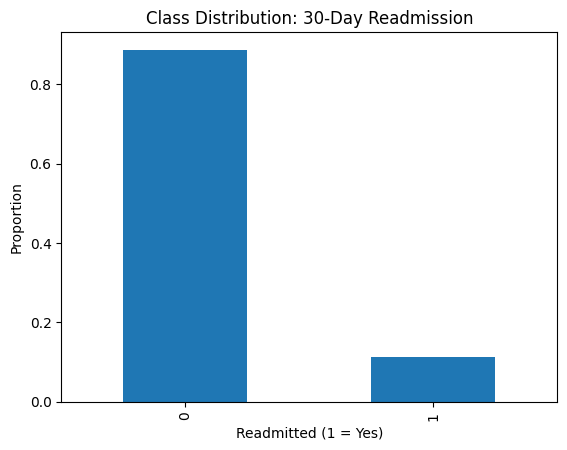

In [ ]:
#EDA
import matplotlib.pyplot as plt

df['target'].value_counts(normalize=True).plot(kind='bar')
plt.title('Class Distribution: 30-Day Readmission')
plt.xlabel('Readmitted (1 = Yes)')
plt.ylabel('Proportion')
plt.show()

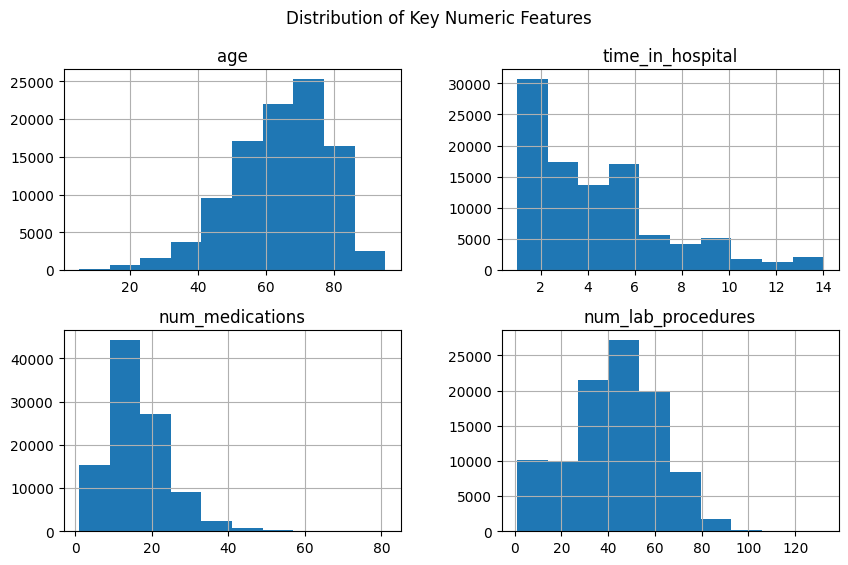

In [ ]:
num_cols = ['age', 'time_in_hospital', 'num_medications', 'num_lab_procedures']

df[num_cols].hist(figsize=(10,6))
plt.suptitle('Distribution of Key Numeric Features')
plt.show()

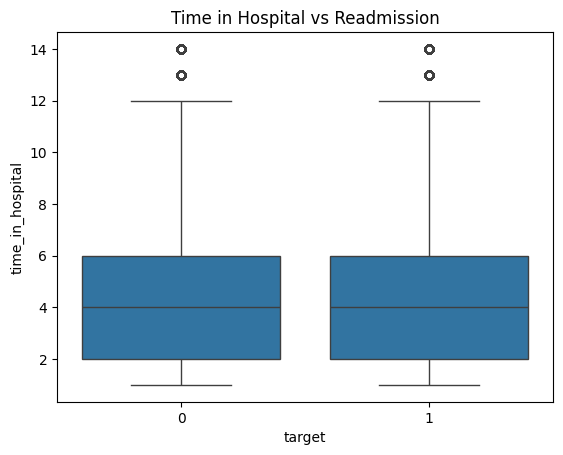

In [ ]:
import seaborn as sns

sns.boxplot(x='target', y='time_in_hospital', data=df)
plt.title('Time in Hospital vs Readmission')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.92      0.70      0.79     17606
           1       0.19      0.54      0.28      2263

    accuracy                           0.68     19869
   macro avg       0.55      0.62      0.53     19869
weighted avg       0.84      0.68      0.73     19869



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
#create 100 trees and vote on the outcome
#class weights - mistake for minority class gets penalized more (more expensive)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

#train the model/brain
rf_model.fit(X_train, y_train)

#Predict on the 'Final Exam' (X_test)
rf_preds = rf_model.predict(X_test)

# results
#precision - few false alarms - quality of the alarm- of the times you stop people, how many were sick?
#recall- out of how many people who were sick/getting to get sick how many did the guard catch? - alot of false alarms
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17606
           1       0.61      0.00      0.01      2263

    accuracy                           0.89     19869
   macro avg       0.75      0.50      0.47     19869
weighted avg       0.86      0.89      0.83     19869



This analysis breaks down the results of the two models. I successfully moved from a model that was "blind" to high-risk patients to one that is a much better clinical screening tool.

1. Random Forest (RF) Model Analysis
The Random Forest model struggled significantly due to the imbalanced nature of the dataset.

- Accuracy (89%): This is a "trap." Because 89% of patients are not readmitted, the model achieved this score by simply predicting 0 for almost everyone.

- Recall for Class 1 (0.00): This is the failure point. The model caught 0% of the actual readmissions. Even with class_weight='balanced', the RF was too conservative.

- Precision (0.61): While high, it’s misleading because the "support" (number of cases it actually predicted as 1) was extremely low.

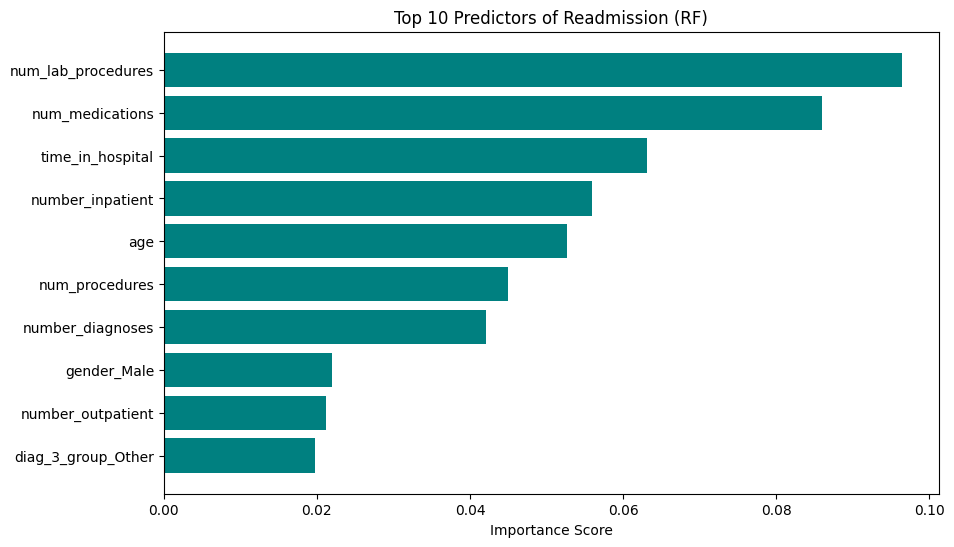

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from the RF model
importances_rf = rf_model.feature_importances_
feature_names = X.columns

# Create a sorted series
feature_importance_df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10
plt.figure(figsize=(10, 6))
#horizontal barchart
plt.barh(feature_importance_df_rf['Feature'], feature_importance_df_rf['Importance'], color='teal')
#top has the #1 (top feature)
plt.gca().invert_yaxis()
plt.title('Top 10 Predictors of Readmission (RF)')
plt.xlabel('Importance Score')
plt.show()

Random Forest Feature Importance:

Top Features: num_lab_procedures, num_medications, time_in_hospital.

Interpretation: The RF looked at "Volume" (how much stuff happened to the patient). While important, these are general stats and don't always point to a specific reason for returning.

In [ ]:
from xgboost import XGBClassifier

#XGBOOST
#sequentially builds the tree and learns from the mistakes
# n_estimators=100 - 100 rounds of learning.
# learning_rate=0.1: How fast the model "updates" its knowledge.
# scale_pos_weight=7.78 - penalty for missing a 1.
xgb_model = XGBClassifier(n_estimators=100,
                           learning_rate=0.1,
                           scale_pos_weight=7.78,
                           random_state=42)

#train
xgb_model.fit(X_train, y_train)

#predict
xgb_preds = xgb_model.predict(X_test)

#eval
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.92      0.70      0.80     17606
           1       0.19      0.54      0.28      2263

    accuracy                           0.68     19869
   macro avg       0.56      0.62      0.54     19869
weighted avg       0.84      0.68      0.74     19869



The XGBoost model, using scale_pos_weight=7.78, performed much better as a medical diagnostic tool.

- Accuracy (68%): While lower than the RF, this is a "healthier" number because the model is finally taking risks to find the sick patients.

- Recall for Class 1 (0.54): This is the success metric. The model successfully identified 54% of all patients who were actually readmitted.

- Precision (0.19): This dropped because the model is now "over-calling" risk. It flags about 5 patients as high-risk to catch 1 true readmission.

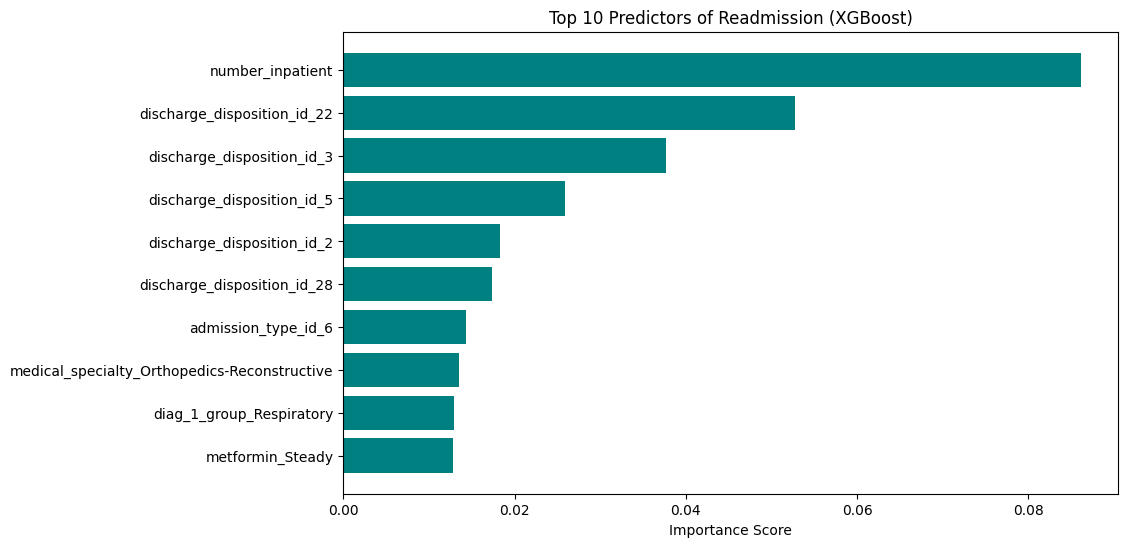

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from the XGBoost model
importances = xgb_model.feature_importances_
feature_names = X.columns

# Create a sorted series
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Predictors of Readmission (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

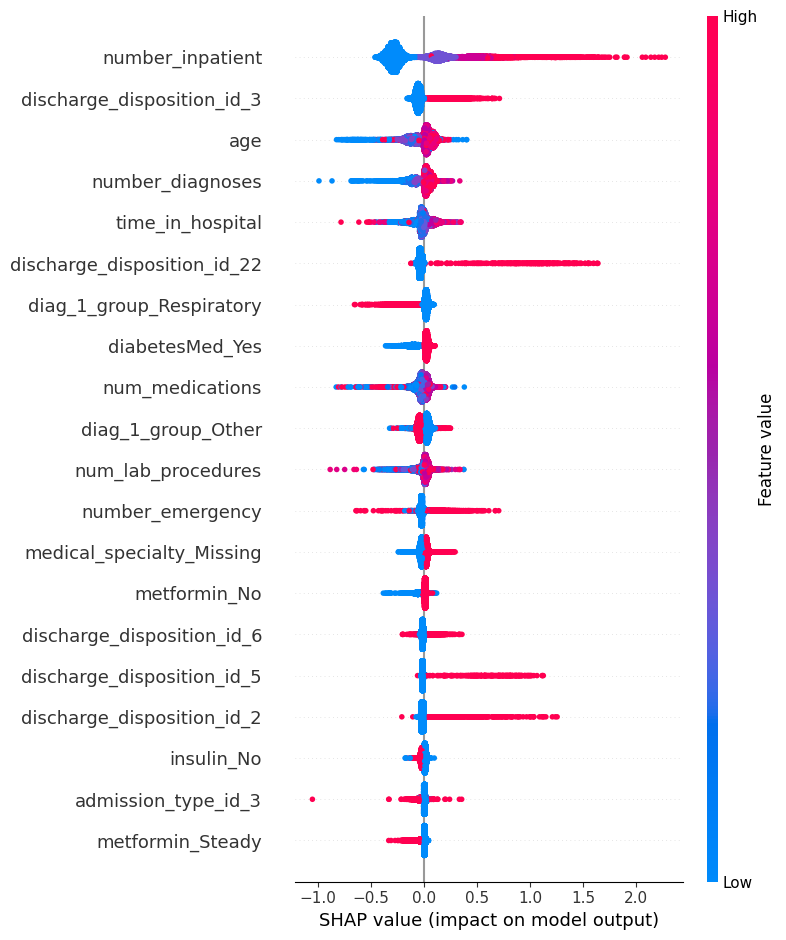

In [ ]:
import shap

# Shap explainer
# This is a specialized tool designed specifically for tree-based models like XGBoost or Random Forest.
# It is incredibly fast and mathematically optimized to calculate the "Shapley values"
# a concept from Game Theory that determines how much "credit" each feature gets for a prediction.

explainer = shap.TreeExplainer(xgb_model)
# Here, the explainer looks at your test set (X_test).
# For every single patient, it runs a simulation: it removes a feature (like age),
# sees how the prediction changes, and repeats this for all combinations of features.
# The result (shap_values) is a matrix of the same size as your data,
# but instead of raw numbers, it contains "impact scores."
# Calculate SHAP values for test set

shap_values = explainer.shap_values(X_test)

# Plot the Summary
# The X-axis (SHAP value): If a dot is to the right of the center line, pushed the prediction toward "Readmitted".
# If it’s to the left, it pushed it toward "Not Readmitted."

#The Color: Red represents a high value of a feature, and Blue represents a low value.
shap.summary_plot(shap_values, X_test)

2. High vs. Low Value (The "What is the Data?")
Value is the actual number or category in your Excel sheet for a specific patient.

- High Value (Red): The number is big (Age = 90, or Inpatient Visits = 10).

- Low Value (Blue): The number is small (Age = 20, or Inpatient Visits = 0).

3. SHAP Value (The "Left or Right")
This is the result of the logic.

Right Side: "This increases the risk of readmission."

Left Side: "This decreases the risk of readmission."

In [ ]:
shap.initjs()

# Visualize the first prediction's explanation
# This shows the 'tug-of-war' between features for one patient
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

In [ ]:
corr_matrix = df_final.corr()
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("Top 5 Factors Increasing Risk:")
print(target_corr.iloc[1:6]) # Start at 1 to skip target correlating with itself

print("\nTop 5 Factors Decreasing Risk:")
print(target_corr.tail(5))

Top 5 Factors Increasing Risk:
number_inpatient               0.168326
discharge_disposition_id_22    0.073452
number_emergency               0.060885
number_diagnoses               0.053580
time_in_hospital               0.046886
Name: target, dtype: float64

Top 5 Factors Decreasing Risk:
race_Unknown               -0.014197
diag_1_group_Respiratory   -0.016874
change_No                  -0.018568
metformin_Steady           -0.023961
insulin_No                 -0.034680
Name: target, dtype: float64


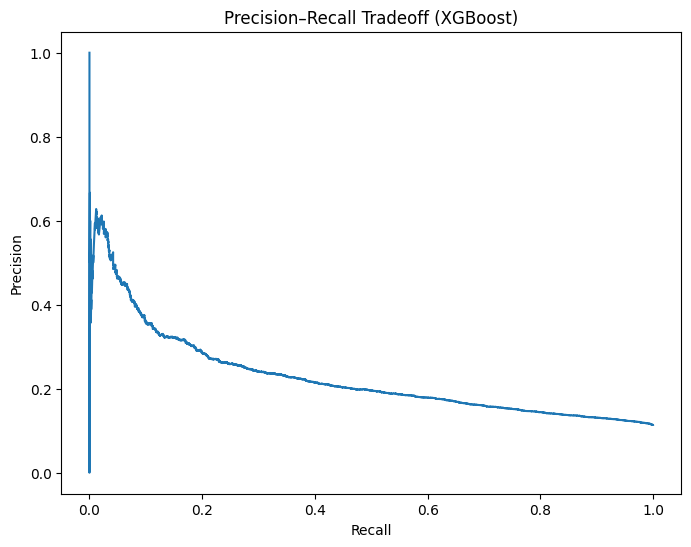

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Tradeoff (XGBoost)")
plt.show()

In [ ]:
target_recall = 0.70

idx = np.argmin(np.abs(recall - target_recall))
chosen_threshold = thresholds[idx]

chosen_threshold

np.float32(0.4351836)

In [ ]:
xgb_preds_custom = (xgb_probs >= chosen_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, xgb_preds_custom))

              precision    recall  f1-score   support

           0       0.93      0.53      0.67     17606
           1       0.16      0.70      0.26      2263

    accuracy                           0.55     19869
   macro avg       0.55      0.61      0.47     19869
weighted avg       0.84      0.55      0.63     19869



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the 'Menu' for RF
# min_samples_split: how many patients needed to create a new branch
# max_depth: how complex the tree can get
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Set up the Search focusing on RECALL
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_param_grid,
                       scoring='recall',
                       cv=3,
                       verbose=1)

# 3. Train
grid_rf.fit(X_train, y_train)

print("Best RF Settings:", grid_rf.best_params_)
# Evaluate the best version
best_rf_model = grid_rf.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Settings: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
from sklearn.model_selection import cross_val_score

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=3,
    scoring='recall'
)

print("XGBoost Recall CV Scores:", xgb_cv_scores)
print("Mean Recall:", xgb_cv_scores.mean())
print("Std Dev:", xgb_cv_scores.std())

XGBoost Recall CV Scores: [0.50878356 0.51375539 0.52933378]
Mean Recall: 0.5172909070820904
Std Dev: 0.008754152155359785
